
## Frequency (Hz)
- Frequency describes the differences of wave lengths.
- We interperate frequency has high and low pitches.

<img src="https://uploads-cdn.omnicalculator.com/images/britannica-wave-frequency.jpg" width="400"/>

## Intensity (db / power)
- Intensity describes the amplitude (height) of the wave.

<img src="https://ars.els-cdn.com/content/image/3-s2.0-B9780124722804500162-f13-15-9780124722804.gif" width="400"/>

## Sample Rate
- Sample rate is specific to how the computer reads in the audio file.
- Think of it as the "resolution" of the audio.

<img src="https://uploads.teachablecdn.com/attachments/mT3ujxzSeOOnxwGJBCEf_Sample_Rate.png" width="400"/>


In [1]:
import librosa

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
audio_path = '/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/13_Audio_Processing_LibRosa/bensound-dubstep.mp3'

In [4]:
music_array, sample_rate = librosa.load(audio_path)

In [18]:
music_array

array([ 1.3775771e-06, -1.9434066e-05, -1.5839205e-05, ...,
       -9.3269051e-04, -1.0657734e-03, -6.5959839e-04], dtype=float32)

In [5]:
music_array.shape

(2753924,)

In [6]:
sample_rate

22050

In [7]:
music_array2, sample_rate2 = librosa.load(audio_path, sr = 44100)

In [8]:
sample_rate2

44100

In [10]:
music_array2.shape

(5507847,)

# Playing audio in ipynb

In [11]:
import IPython.display as ipd

ipd.Audio(audio_path)

Output hidden; open in https://colab.research.google.com to view.

# Audio Signals or Waveform Visualization

In [12]:
import matplotlib.pyplot as plt

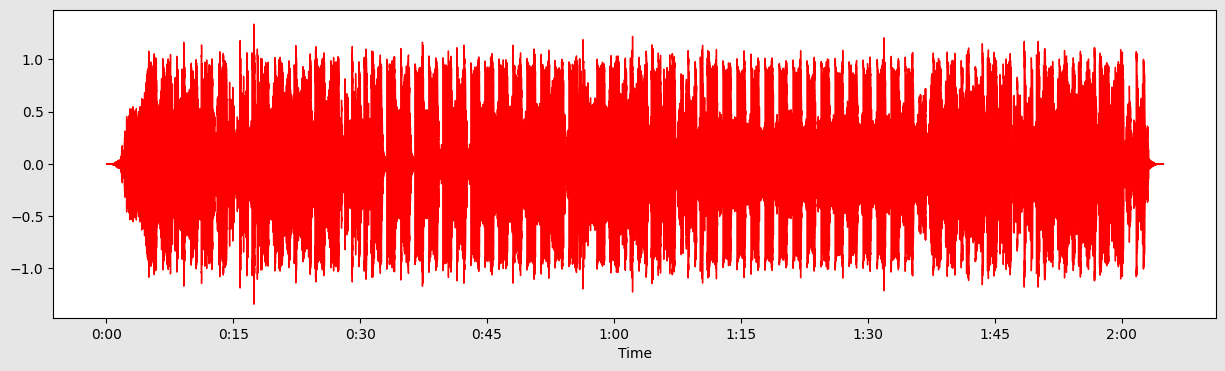

In [16]:
plt.figure(figsize=(15,4),facecolor=(0.9,0.9,0.9))
librosa.display.waveshow(music_array2,sr=sample_rate2, color='red')

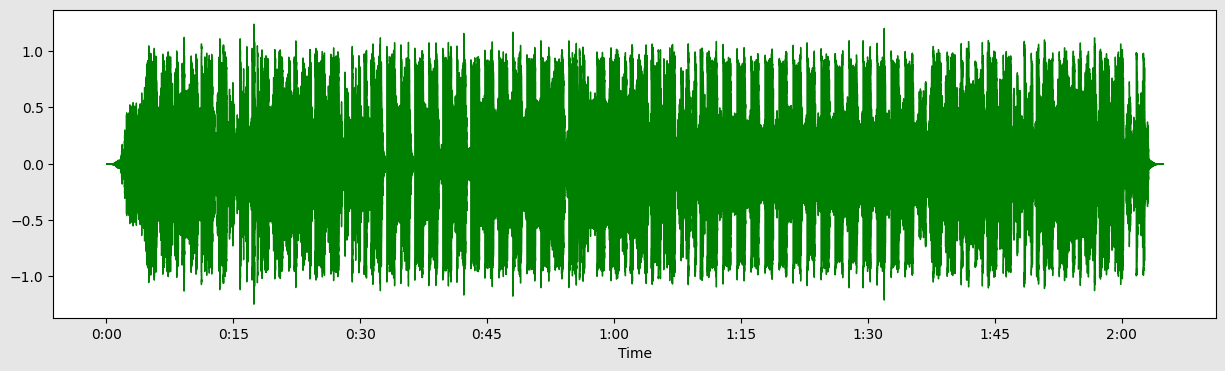

In [17]:
plt.figure(figsize=(15,4),facecolor=(0.9,0.9,0.9))
librosa.display.waveshow(music_array,sr=sample_rate, color='green')

# Spectrogram Visualization

In [23]:
X = librosa.stft(music_array2) #stft: short-time fourier transform
Xdb = librosa.amplitude_to_db(abs(X)) #Xdb: spectrogram in decibel scall

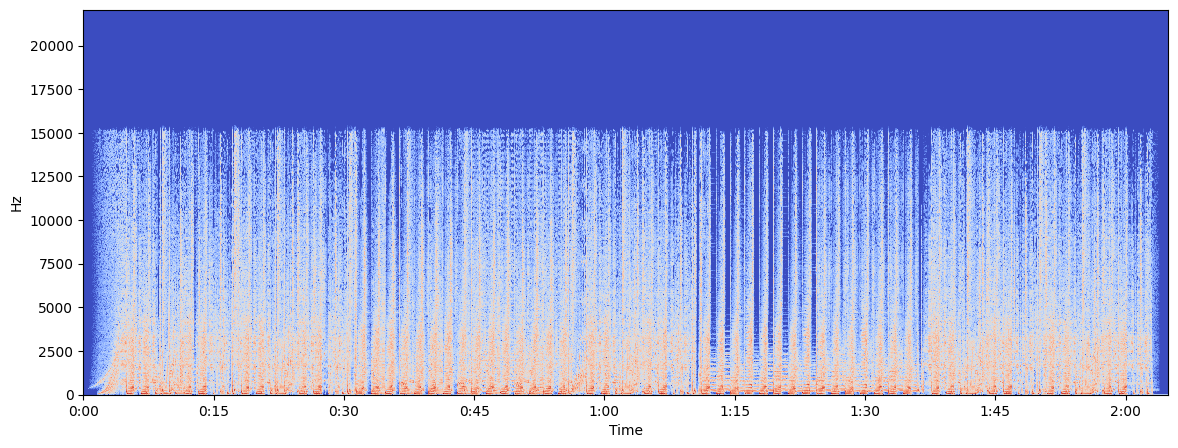

In [25]:
plt.figure(figsize=(14,5))
librosa.display.specshow(Xdb, sr = sample_rate2, x_axis='time', y_axis = 'hz')

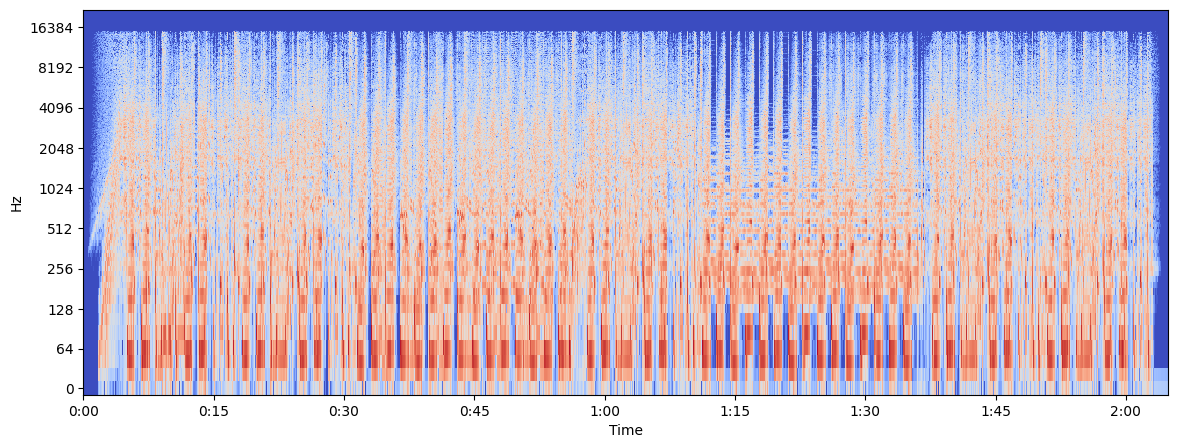

In [26]:
plt.figure(figsize=(14,5))
librosa.display.specshow(Xdb, sr = sample_rate2, x_axis='time', y_axis = 'log')

# Audio Generation

In [28]:
import numpy as np

In [27]:
sample_rate = 22050
total_time = 5.0

In [29]:
22050*5

110250

In [31]:
time_x = np.linspace(0, total_time, int(total_time*sample_rate), endpoint=False)

In [32]:
len(time_x)

110250

In [34]:
#sine wave at 22khz

x = 0.5*np.sin(2*np.pi*220*time_x) #A.sin(2*Pi*f*T)

In [35]:
x.shape

(110250,)

In [36]:
amplitude = np.sin(time_x)

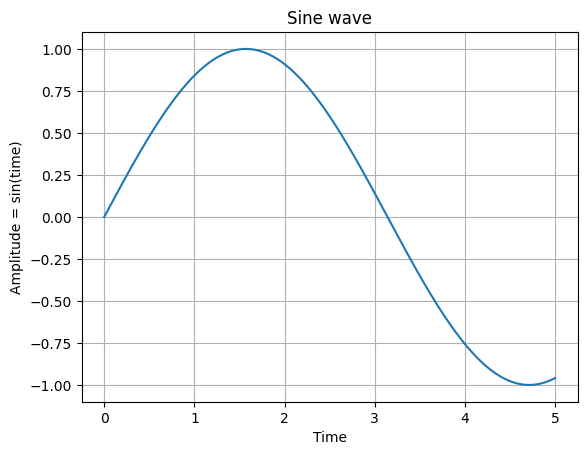

In [39]:
plt.plot(time_x, amplitude)
plt.title('Sine wave')
plt.xlabel('Time')
plt.ylabel('Amplitude = sin(time)')
plt.grid(True, which='both')
plt.show()

# Playing the Audio

In [40]:
ipd.Audio(x,rate=sample_rate)

In [41]:
x = 0.5*np.sin(2*np.pi*220*time_x)+0.3*np.sin(2*np.pi*440*time_x)+0.8*np.sin(2*np.pi*660*time_x)

In [42]:
ipd.Audio(x,rate=sample_rate)

In [44]:
modulator = np.sin(2*np.pi*2*time_x) #2Hz pulse
x = (0.5*np.sin(2*np.pi*440*time_x))*(1+ 0.5*modulator)

In [45]:
ipd.Audio(x,rate=sample_rate)

In [61]:
freqs = [220,330,440,550,660,770,220,330,440,550,660,220,440,550,660]
#freqs = [10,20,40,50,60]
x = np.concatenate([0.5*np.sin(2*np.pi*f*np.linspace(0, total_time/len(freqs), int(total_time*sample_rate/len(freqs)), endpoint=False))
for f in freqs])

In [60]:
ipd.Audio(x,rate=sample_rate)

In [51]:
[0.5*np.sin(2*np.pi*f*np.linspace(0, total_time/len(freqs), int(total_time*sample_rate/len(freqs)), endpoint=False))
for f in freqs]

[array([ 0.        ,  0.03132416,  0.06252526, ..., -0.09348072,
        -0.06252526, -0.03132416]),
 array([ 0.        ,  0.04694777,  0.09348072, ..., -0.13918768,
        -0.09348072, -0.04694777]),
 array([ 0.        ,  0.06252526,  0.12406892, ..., -0.1836648 ,
        -0.12406892, -0.06252526]),
 array([ 0.        ,  0.07804133,  0.1541697 , ..., -0.22651907,
        -0.1541697 , -0.07804133]),
 array([ 0.        ,  0.09348072,  0.1836648 , ..., -0.26737184,
        -0.1836648 , -0.09348072])]

In [56]:
import soundfile as sf

In [58]:
sf.write('/content/drive/MyDrive/Daksh_Gururkul_IITG_May_2025/13_Audio_Processing_LibRosa/sample_sound.wav',
         x, samplerate=22050)